1-step History MLP Gridworld Experiment
Goal: Increase complexity of MLP by including the previous step's information as input and increase distinguishability between to same observations

Results observation: the training loss improved as the increased data allows for better fit to the training set, but the validation loss worsened, further indicating that the current NN architecture has a tendency to overfit.

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from functions.gridworld import GridWorld, Agent
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/seblee/miniconda3/envs/main/bin/python
2.14.0+cu130


State variables

In [5]:

HEIGHT = 20
WIDTH = 25
VIEW_SIZE = 5

START_X = 6
START_Y = 6
START_DIRECTION = 2

N_STEPS = 500

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]

SEED = 42

Gridworld Creation

In [6]:
grid = GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(5, 10, 5, 20)
grid.add_rectangle_region(10, 15, 10, 15)
grid.add_square_shape(6, 6, 3, 7)
grid.add_triangle_shape(6, 11, 3, 0, 6)
grid.add_single_shape(7, 17, 5)
grid.add_single_shape(6, 16, 5)
grid.add_single_shape(6, 18, 5)
grid.add_single_shape(8, 16, 5)
grid.add_single_shape(8, 18, 5)
grid.add_rectangle_shape(11, 12, 3, 1, 3)
grid.add_rectangle_shape(12, 11, 1, 3, 4)


Trajectory Generation Function

In [7]:
def generate_trajectory(grid, start_x, start_y, start_direction, view_size, n_steps, seed):
    
    agent = Agent(start_x, start_y, view_size, grid, start_direction)   #Create agent

    rng = np.random.default_rng(seed)

    for i in range(n_steps):                                            #Agent random walk
        action = rng.choice([0, 1, 2, 3], p=[0.6, 0.15, 0.15, 0.1])

        if action == 0:
            agent.move()
            #print(f"moved towards {agent.direction}")
        elif action == 3:
            agent.stop()
            #print("stopped")
        else:

            agent.rotate(action)
            #print(f"rotated towards {agent.direction}")
        observation = agent.observe()
        #print(pd.DataFrame(observation))

    #print(agent.states)
    print(len(agent.states))
    print(len(agent.observations))
    print(len(agent.actions))

    return agent

Trajectory Data Formatting Function

Now that the input is expanded to also contain the previous step, the data formatting has to be able to accomodate the previous step too

In [8]:
def prepare_data(agent):                                                                #Conversion to tensors
    observations = torch.tensor(
        np.array(agent.observations),
        dtype = torch.float32
    )
    actions = torch.tensor(
        agent.actions, 
        dtype = torch.long
    )
    states = torch.tensor(
        agent.states,
        dtype = torch.long
    )
    print(observations.shape)
    print(actions.shape)
    print(states.shape)
    observations = observations.flatten(start_dim = 1)
    print(observations.shape)
    actions_onehot = torch.nn.functional.one_hot(
        actions,
        num_classes = 4
    ).float()
    print(actions_onehot.shape)
    input_obs = observations[:-1]
    target_obs = observations[1:]
    inputs = torch.cat(
        (input_obs, actions_onehot),
        dim = 1
    )
    blank = torch.zeros_like(inputs[:1])

    previous_steps_inputs = torch.cat(
        (blank, inputs[:-1]),
        dim = 0
    )
    new_inputs = torch.cat(
        (previous_steps_inputs, 
        inputs),
        dim = 1
    )

    print("input observations: ", input_obs.shape)
    print("actions: ", actions_onehot.shape)
    print("1-step-history NN inputs: ", new_inputs.shape)
    print("targets: ", target_obs.shape)
    
    return new_inputs, target_obs

NN Model Creation Function

In [9]:

def model_creation(input, output, hidden_size):

    model = nn.Sequential(
        nn.Linear(trainer_data_inputs.shape[1], hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output.shape[1])
    )
    return model

Model Evaluation Function

In [10]:

def model_evaluation(model, observation, inputs, name):

    loss_fn = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        prediction = model(inputs)
        test_loss = loss_fn(prediction, observation)
    print(test_loss.item())

    print(f"Test loss, {name}: ", test_loss.item())

    return test_loss.item()

Baseline Evaluation Function

In [11]:

def baseline_evaluation(inputs, targets):
    observation_size = targets.shape[1]

    baseline_prediction = inputs[:, :observation_size]
    loss_fn = nn.MSELoss()
    baseline_loss = loss_fn(baseline_prediction, targets)

    print("Baseline loss: ", baseline_loss.item())


Model Training Function

In [12]:

def model_training(model, input, output):

    loss_fn = nn.MSELoss()

    loss_history = []

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    trainer_error_log = []
    validator_error_log = []
    epochs_recorded = []
    for epoch in range(1000):
        optimizer.zero_grad()
        prediction = model(input)

        loss = loss_fn(prediction, output)
        loss_history.append(loss.item())
        loss.backward()

        optimizer.step()

        if epoch % 100 == 0:
            #print(epoch, loss.item())
            trainer_error = model_evaluation(model_NN, trainer_data_target_obs, trainer_data_inputs, "trainer")
            validator_error = model_evaluation(model_NN, validator_data_target_obs, validator_data_inputs, "validator")
            trainer_error_log.append(trainer_error)
            validator_error_log.append(validator_error)
            epochs_recorded.append(epoch)

    plt.plot(epochs_recorded, trainer_error_log, label = "training")
    plt.plot(epochs_recorded, validator_error_log, label = "test")
    plt.xlabel("epoch")
    plt.ylabel("error")
    plt.legend()
    plt.show()

    return loss_history

NN Training and Validation

501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
1-step-history NN inputs:  torch.Size([500, 58])
targets:  torch.Size([500, 25])
201
201
200
torch.Size([201, 5, 5])
torch.Size([200])
torch.Size([201, 3])
torch.Size([201, 25])
torch.Size([200, 4])
input observations:  torch.Size([200, 25])
actions:  torch.Size([200, 4])
1-step-history NN inputs:  torch.Size([200, 58])
targets:  torch.Size([200, 25])
4.329808712005615
Test loss, trainer:  4.329808712005615
7.289793014526367
Test loss, validator:  7.289793014526367
2.2033374309539795
Test loss, trainer:  2.2033374309539795
4.219951152801514
Test loss, validator:  4.219951152801514
1.711537480354309
Test loss, trainer:  1.711537480354309
4.132983207702637
Test loss, validator:  4.132983207702637
1.3733869791030884
Test loss, trainer:  1.3733869791030884
4.246797561645508
Test loss, validator:  4.24

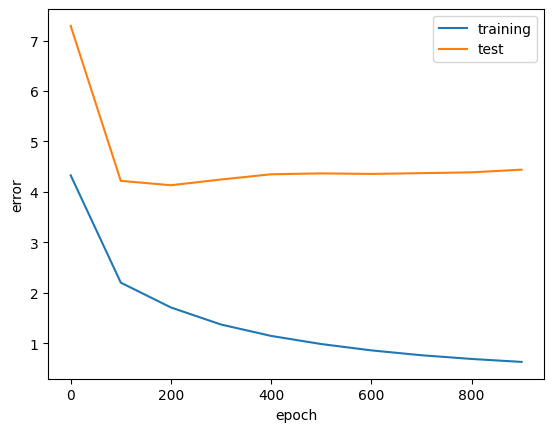

0.5834066867828369
Test loss, trainer:  0.5834066867828369
4.546629428863525
Test loss, validator:  4.546629428863525
Baseline loss:  10.902000427246094


In [13]:

trainer_agent = generate_trajectory(grid, START_X, START_Y, START_DIRECTION, VIEW_SIZE, N_STEPS, SEED)
trainer_data_inputs, trainer_data_target_obs = prepare_data(trainer_agent)

TEST_SEED = 123
TEST_STEPS = 200

validator_agent = generate_trajectory(grid, START_X, START_Y, START_DIRECTION, VIEW_SIZE, TEST_STEPS, TEST_SEED)
validator_data_inputs, validator_data_target_obs = prepare_data(validator_agent)

INPUT_SIZE = trainer_data_inputs.shape[1]
OUTPUT_SIZE = trainer_data_target_obs.shape[1]
HIDDEN_SIZE = 64     


model_NN = model_creation(trainer_data_inputs, trainer_data_target_obs, HIDDEN_SIZE)
loss_history = model_training(model_NN, trainer_data_inputs, trainer_data_target_obs)


model_evaluation(model_NN, trainer_data_target_obs, trainer_data_inputs, "trainer")
model_evaluation(model_NN, validator_data_target_obs, validator_data_inputs, "validator")
baseline_evaluation(validator_data_inputs, validator_data_target_obs)



validator Error per Action Type

There are t predictions, t + 1 observations and t actions
predictions start from 

In [14]:
validator_agent_actions = validator_agent.actions
trainer_agent_actions = trainer_agent.actions

validator_action_move = []
validator_action_left = []
validator_action_right = []
validator_action_stop = []
baseline_validator_action_move = []
baseline_validator_action_left = []
baseline_validator_action_right = []
baseline_validator_action_stop = []
trainer_action_move = []
trainer_action_left = []
trainer_action_right = []
trainer_action_stop = []

model_NN.eval()

with torch.no_grad():
    validator_pred_obs = model_NN(validator_data_inputs)
    trainer_pred_obs = model_NN(trainer_data_inputs)

loss_fn = nn.MSELoss(reduction = "none")


validator_loss = loss_fn(validator_data_target_obs, validator_pred_obs)
trainer_loss = loss_fn(trainer_data_target_obs, trainer_pred_obs)

observations_size = validator_data_target_obs.shape[1]
validator_data_target_obs_minusone = validator_data_inputs[:, :observations_size]

baseline_loss = loss_fn(validator_data_target_obs, validator_data_target_obs_minusone)

avg_validator_loss = validator_loss.mean(dim = 1)
avg_trainer_loss = trainer_loss.mean(dim = 1)

i = 0
for actions in validator_agent_actions:
    if actions == 0:
        validator_action_move.append(avg_validator_loss[i])
        baseline_validator_action_move.append(baseline_loss[i])
    elif actions == 1:
        validator_action_left.append(avg_validator_loss[i])
        baseline_validator_action_left.append(baseline_loss[i])
    elif actions == 2:
        validator_action_right.append(avg_validator_loss[i])
        baseline_validator_action_right.append(baseline_loss[i])
    elif actions == 3:
        validator_action_stop.append(avg_validator_loss[i])
        baseline_validator_action_stop.append(baseline_loss[i])
    i += 1

j = 0
for actions in trainer_agent_actions:
    if actions == 0:
        trainer_action_move.append(avg_trainer_loss[j])
    elif actions == 1:
        trainer_action_left.append(avg_trainer_loss[j])
    elif actions == 2:
        trainer_action_right.append(avg_trainer_loss[j])
    elif actions == 3:
        trainer_action_stop.append(avg_trainer_loss[j])
    j += 1

validator_move_loss = torch.stack(validator_action_move).mean()
validator_left_loss = torch.stack(validator_action_left).mean()
validator_right_loss = torch.stack(validator_action_right).mean()
validator_stop_loss = torch.stack(validator_action_stop).mean()
trainer_move_loss = torch.stack(trainer_action_move).mean()
trainer_left_loss = torch.stack(trainer_action_left).mean()
trainer_right_loss = torch.stack(trainer_action_right).mean()
trainer_stop_loss = torch.stack(trainer_action_stop).mean()
baseline_move_loss = torch.stack(baseline_validator_action_move).mean()
baseline_left_loss = torch.stack(baseline_validator_action_left).mean()
baseline_right_loss = torch.stack(baseline_validator_action_right).mean()
baseline_stop_loss = torch.stack(baseline_validator_action_stop).mean()

print(f"move loss: {validator_move_loss}, {len(validator_action_move)}")
print(f"left loss: {validator_left_loss}, {len(validator_action_left)}")
print(f"right loss: {validator_right_loss}, {len(validator_action_right)}")
print(f"stop loss: {validator_stop_loss}, {len(validator_action_stop)}")

print(f"trainer move loss: {trainer_move_loss}, {len(trainer_action_move)}")
print(f"trainer left loss: {trainer_left_loss}, {len(trainer_action_left)}")
print(f"trainer right loss: {trainer_right_loss}, {len(trainer_action_right)}")
print(f"trainer stop loss: {trainer_stop_loss}, {len(trainer_action_stop)}")

print(f"baseline_move loss: {baseline_move_loss}, {len(baseline_validator_action_move)}")
print(f"baseline_left loss: {baseline_left_loss}, {len(baseline_validator_action_left)}")
print(f"baseline_right loss: {baseline_right_loss}, {len(baseline_validator_action_right)}")
print(f"baseline_stop loss: {baseline_stop_loss}, {len(baseline_validator_action_stop)}")


validator_global_avg_loss = (validator_move_loss * len(validator_action_move) + validator_left_loss * len(validator_action_left) + validator_right_loss * len(validator_action_right) + validator_stop_loss * len(validator_action_stop)) / 200
trainer_global_avg_loss = (trainer_move_loss * len(trainer_action_move) + trainer_left_loss * len(trainer_action_left) + trainer_right_loss * len(trainer_action_right) + trainer_stop_loss * len(trainer_action_stop)) / 500

print(f"validator Global Average Loss: {validator_global_avg_loss}")
print(f"Trainer Global Average Loss: {trainer_global_avg_loss}")



move loss: 2.7725565433502197, 127
left loss: 7.5948944091796875, 25
right loss: 7.23391580581665, 31
stop loss: 8.416910171508789, 17
trainer move loss: 0.3010551631450653, 300
trainer left loss: 1.1670644283294678, 76
trainer right loss: 1.025435447692871, 79
trainer stop loss: 0.704010546207428, 45
baseline_move loss: 9.996535301208496, 127
baseline_left loss: 12.363200187683105, 25
baseline_right loss: 14.131612777709961, 31
baseline_stop loss: 9.62823486328125, 17
validator Global Average Loss: 4.546629428863525
Trainer Global Average Loss: 0.5834066867828369


A Standard NN is memoryless, so if for two different states, the same observation is presented and the same action is chosen, the input to the NN are effectively the same, with no distinguishability. The next goal is to show that this is an issue with standard MLPs.

Find scenarios where (o_t, a_t) are equal but o_t+1 are different at the next step. then compare the predicted o_t+1 and see how similar they are one to the other

In [15]:
trainer_validator_inputs = torch.cat((trainer_data_inputs, validator_data_inputs), dim = 0)
equal_input_pairs = []

groups = {}

for i in range(len(trainer_validator_inputs)):
    key = tuple(trainer_validator_inputs[i].tolist())

    if key not in groups:
        groups[key] = []

    groups[key].append(i)

multiinput_count = 0
oneinput_count = 0
for key, number in groups.items():
    if len(number) > 1:
        print(number)
        multiinput_count += 1
    else:
        oneinput_count += 1
    if len(number) == 2:
        print(f"occurences: {len(number)}")

        key_tensor = torch.tensor(key)
        observation = key_tensor[:25].reshape(5, 5)
        action = key_tensor[25:]

        #print(observation)
        #print(action)

#print(multiinput_count)
#print(oneinput_count)


[5, 109]
occurences: 2
[10, 502]
occurences: 2
[15, 504]
occurences: 2
[28, 57, 58, 59, 302, 303, 309, 310, 311, 312, 313, 314, 315, 316, 392, 398, 399, 400, 464, 489, 520, 521, 522, 523, 524, 525, 526, 630, 699]
[29, 60, 317, 328, 364, 393, 465, 490, 527, 605, 631]
[40, 448]
occurences: 2
[47, 444]
occurences: 2
[48, 445]
occurences: 2
[52, 290, 304, 389]
[62, 125]
occurences: 2
[64, 80]
occurences: 2
[65, 78, 81, 87, 120, 275]
[66, 67, 68, 69, 70, 71, 88, 89, 90, 127, 128, 129, 130, 133, 134, 135, 259, 260, 276, 277]
[72, 79, 82, 138, 261, 278]
[73, 83, 139, 262]
[74, 75, 76, 84, 85, 140, 141, 144, 145, 146, 147, 148, 149, 263, 266, 267, 268, 269, 270, 271, 272, 273]
[77, 86, 274]
[91, 121]
occurences: 2
[93, 153]
occurences: 2
[94, 154]
occurences: 2
[95, 155]
occurences: 2
[96, 156]
occurences: 2
[111, 112, 113, 114, 437]
[131, 136]
occurences: 2
[132, 137]
occurences: 2
[142, 264]
occurences: 2
[143, 265]
occurences: 2
[163, 476, 552]
[164, 553]
occurences: 2
[165, 554, 555]
[166,

Consider which equal scenarios contain a different next observation, and also compare with predicted observation

In [16]:
trainer_validator_target_obs = torch.cat((trainer_data_target_obs, validator_data_target_obs), dim = 0)


for key, indices in groups.items():
    if len(indices) > 1:
        matching_set = set()
        for i in indices:
            target_key = tuple(trainer_validator_target_obs[i].tolist())
            matching_set.add(target_key)

        print(f"Occurences: {len(indices)}")
        print(f"Matching sets: {(len(matching_set))}")
        print(f"Indices: {indices}")





Occurences: 2
Matching sets: 1
Indices: [5, 109]
Occurences: 2
Matching sets: 1
Indices: [10, 502]
Occurences: 2
Matching sets: 1
Indices: [15, 504]
Occurences: 29
Matching sets: 1
Indices: [28, 57, 58, 59, 302, 303, 309, 310, 311, 312, 313, 314, 315, 316, 392, 398, 399, 400, 464, 489, 520, 521, 522, 523, 524, 525, 526, 630, 699]
Occurences: 11
Matching sets: 8
Indices: [29, 60, 317, 328, 364, 393, 465, 490, 527, 605, 631]
Occurences: 2
Matching sets: 1
Indices: [40, 448]
Occurences: 2
Matching sets: 1
Indices: [47, 444]
Occurences: 2
Matching sets: 1
Indices: [48, 445]
Occurences: 4
Matching sets: 4
Indices: [52, 290, 304, 389]
Occurences: 2
Matching sets: 1
Indices: [62, 125]
Occurences: 2
Matching sets: 1
Indices: [64, 80]
Occurences: 6
Matching sets: 1
Indices: [65, 78, 81, 87, 120, 275]
Occurences: 20
Matching sets: 1
Indices: [66, 67, 68, 69, 70, 71, 88, 89, 90, 127, 128, 129, 130, 133, 134, 135, 259, 260, 276, 277]
Occurences: 6
Matching sets: 1
Indices: [72, 79, 82, 138, 261, 2